In [ ]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import norm, t, binom, poisson, expon, chi2, f
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import statsmodels.api as sm
from statsmodels import stats as sm_stats
from statsmodels.stats import weightstats as sswa
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats import proportion as ssp
from statsmodels.stats.proportion import proportions_ztest
import os
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [19]:
import os
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

In [20]:
df = pd.read_excel('data/SalesData1.xlsx')

In [21]:
df.head()

,Sales,Ad_Budget,Store_Size,Region
0,268.093732,44,2836,East
1,441.660841,96,2656,North
2,347.500444,76,615,North
3,297.618111,64,2036,West
4,203.849511,24,2211,East


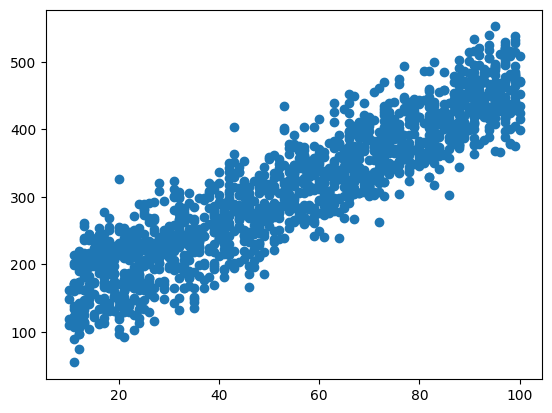

In [22]:
sales = df.Sales
budget = df.Ad_Budget
plt.scatter(budget,sales)
plt.show()

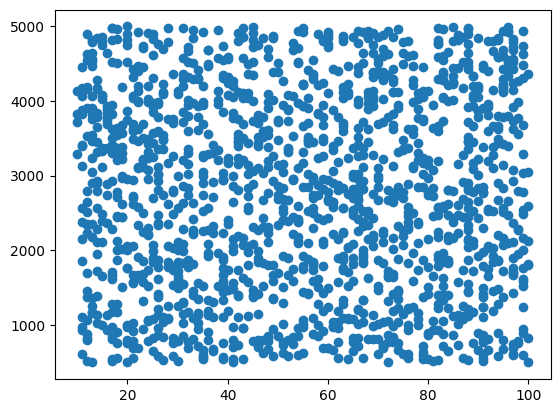

In [23]:
store_size = df.Store_Size
plt.scatter(budget,store_size)
plt.show()

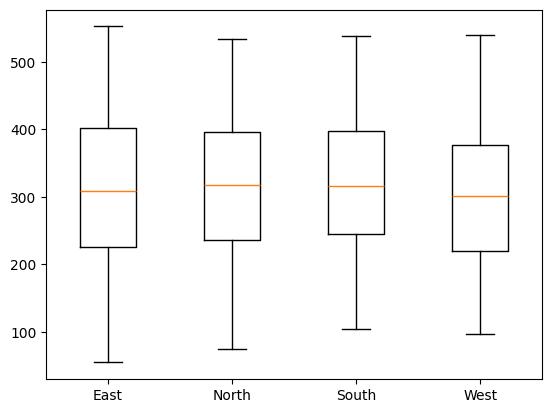

In [24]:
x1 = df.Sales[df.Region=='East']
x2 = df.Sales[df.Region=='North']
x3 = df.Sales[df.Region=='South']
x4 = df.Sales[df.Region=='West']

labs = ['East','North','South','West']

plt.boxplot([x1,x2,x3,x4], labels=labs)
plt.show()

In [ ]:
# one sample z - test = population sd known, test the mean
# one sample t - test = population sd unknown, test mean on sample 

In [25]:
model = ols('Sales~Region',df).fit()
res=sm.stats.anova_lm(model)
print(res)

              df        sum_sq       mean_sq         F    PR(>F)
Region       3.0  8.524669e+04  28415.562482  2.756758  0.041113
Residual  1496.0  1.542017e+07  10307.600751       NaN       NaN


In [26]:
print(pairwise_tukeyhsd(df.Sales, df.Region))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  East  North   1.2061 0.9985 -17.8715 20.2836  False
  East  South   8.8528 0.6263 -10.1059 27.8115  False
  East   West -12.1844 0.3468 -31.0919  6.7232  False
 North  South   7.6467 0.7364 -11.5915 26.8849  False
 North   West -13.3904 0.2762 -32.5782  5.7973  False
 South   West -21.0371 0.0238 -40.1068 -1.9675   True
-----------------------------------------------------


In [27]:
model = ols('Sales~Region',df).fit()
res=sm.stats.anova_lm(model)
print(res)

              df        sum_sq       mean_sq         F    PR(>F)
Region       3.0  8.524669e+04  28415.562482  2.756758  0.041113
Residual  1496.0  1.542017e+07  10307.600751       NaN       NaN


In [28]:
reg_dummy = pd.get_dummies(df.Region,drop_first=True).astype(int)
df = df.drop('Region', axis=1)
df=pd.concat([df,reg_dummy], axis=1)

x_train,x_test,y_train,y_test = train_test_split(df.drop('Sales',axis=1), df.Sales, random_state = 20, test_size=0.1)

x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     2101.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:39:38   Log-Likelihood:                -6682.4
No. Observations:                1350   AIC:                         1.338e+04
Df Residuals:                    1344   BIC:                         1.341e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Ad_Budget      3.4885      0.035     98.332      0.0

**interpreting OLS regression results: null hypothesis testing and decision criteria**

**overall model significance (F-test)**

the F-statistic tests the overall model significance with the following hypotheses:
- H₀: all regression coefficients are zero (model has no predictive power)
- H₁: at least one coefficient is non-zero (model explains some variance)

decision rule: reject H₀ if p-value < α (typically 0.05)

result: F-statistic = 2101, Prob(F-statistic) = 0.00
- decision: reject H₀
- interpretation: the model as a whole is statistically significant. at least one predictor significantly explains sales variance.
- model fit: R² = 0.887 means 88.7% of sales variance is explained by the predictors.

**individual coefficient tests (t-tests)**

each coefficient has its own hypothesis test:
- H₀: β = 0 (predictor has no effect on sales)
- H₁: β ≠ 0 (predictor has a significant effect)

decision factors to consider:
1. **p-value (P>|t|)**: reject H₀ if p < 0.05
2. **t-statistic**: larger absolute values indicate stronger evidence against H₀
3. **confidence interval [0.025, 0.975]**: if interval excludes 0, reject H₀
4. **coefficient sign and magnitude**: practical significance

**coefficient-by-coefficient interpretation**

1. **Ad_Budget** (coef = 3.4885, p = 0.000)
   - H₀: ad budget has no effect on sales
   - decision: reject H₀ (p < 0.001)
   - interpretation: for every unit increase in ad budget, sales increase by 3.49 units (holding other variables constant). highly significant predictor.
   - confidence interval [3.419, 3.558] excludes zero, confirming significance.

2. **Store_Size** (coef = 0.0187, p = 0.000)
   - H₀: store size has no effect on sales
   - decision: reject H₀ (p < 0.001)
   - interpretation: each unit increase in store size increases sales by 0.019 units. statistically significant but smaller practical effect compared to ad budget.
   - confidence interval [0.017, 0.020] excludes zero.

3. **North** (coef = -3.6628, p = 0.165)
   - H₀: sales in north region do not differ from east region (reference category)
   - decision: fail to reject H₀ (p = 0.165 > 0.05)
   - interpretation: no statistically significant difference in sales between north and east regions. the negative coefficient suggests lower sales, but the evidence is insufficient to conclude this is a real effect rather than random variation.
   - confidence interval [-8.839, 1.513] includes zero, indicating non-significance.

4. **South** (coef = 11.0189, p = 0.000)
   - H₀: sales in south region do not differ from east region
   - decision: reject H₀ (p < 0.001)
   - interpretation: south region has significantly higher sales than east (reference) by 11.02 units on average, controlling for other factors.
   - confidence interval [5.869, 16.169] excludes zero.

5. **West** (coef = -6.0024, p = 0.022)
   - H₀: sales in west region do not differ from east region
   - decision: reject H₀ (p = 0.022 < 0.05)
   - interpretation: west region has significantly lower sales than east by 6.00 units on average. marginally significant (p close to 0.05 threshold).
   - confidence interval [-11.144, -0.861] excludes zero, but barely (lower bound close to zero suggests weaker evidence).

6. **const (intercept)** (coef = 68.1977, p = 0.000)
   - H₀: intercept = 0
   - decision: reject H₀
   - interpretation: when all predictors are zero (ad budget = 0, store size = 0, east region), expected sales = 68.20 units. this is the baseline sales level.

**key decision factors summary**

when deciding to reject or fail to reject H₀, examine:

1. **p-value threshold**: typically α = 0.05
   - p < 0.05 → reject H₀ (significant)
   - p ≥ 0.05 → fail to reject H₀ (not significant)

2. **confidence interval**: does it include zero?
   - excludes 0 → significant effect
   - includes 0 → effect not significant

3. **t-statistic magnitude**: 
   - |t| > 2 (roughly) → likely significant
   - larger |t| → stronger evidence

4. **practical vs statistical significance**:
   - small p-value does not mean large effect
   - consider coefficient magnitude in context

5. **model assumptions**: 
   - check residual plots, normality, homoscedasticity
   - violations may invalidate p-values

**conclusion for this model**

predictors with significant effects (reject H₀):
- Ad_Budget (strongest predictor)
- Store_Size
- South region (positive effect)
- West region (negative effect, marginally significant)

predictors with no significant effect (fail to reject H₀):
- North region (not different from east reference category)

regional interpretation: using east as reference, south performs better while west performs worse. north shows no statistical difference from east.

In [ ]:
# Ho -  OLS model does not explain enough variation in the output -> rejected
# H1 -  does explain enough variation in the output

**understanding OLS regression statistics: formulas and calculations**

**model-level statistics (top section)**

1. **R-squared (R²)**
   - formula: R² = 1 - (SSR / SST)
   - where: SSR = sum of squared residuals, SST = total sum of squares
   - calculation: R² = 1 - Σ(yᵢ - ŷᵢ)² / Σ(yᵢ - ȳ)²
   - interpretation: proportion of variance in dependent variable explained by the model
   - range: 0 to 1 (higher is better, but be cautious of overfitting)

2. **Adjusted R-squared (Adj. R²)**
   - formula: Adj. R² = 1 - [(1 - R²) × (n - 1) / (n - k - 1)]
   - where: n = number of observations, k = number of predictors
   - calculation: penalizes adding predictors that don't improve the model
   - interpretation: R² adjusted for number of predictors; use when comparing models with different numbers of variables

3. **F-statistic**
   - formula: F = (R² / k) / [(1 - R²) / (n - k - 1)]
   - alternative: F = MSR / MSE = (explained variance) / (unexplained variance)
   - where: MSR = mean square regression, MSE = mean square error
   - calculation: F = [(SST - SSR) / k] / [SSR / (n - k - 1)]
   - interpretation: tests overall model significance (all coefficients jointly)
   - distribution: follows F-distribution with k and (n-k-1) degrees of freedom

4. **Prob (F-statistic)**
   - calculation: p-value from F-distribution with df1=k, df2=n-k-1
   - interpretation: probability of observing this F-statistic if all coefficients were zero
   - decision: p < 0.05 means model is statistically significant

5. **Log-Likelihood**
   - formula: ln(L) = -n/2 × ln(2π) - n/2 × ln(σ²) - 1/(2σ²) × Σ(yᵢ - ŷᵢ)²
   - interpretation: measures how well the model fits the data (higher is better)
   - used for model comparison via AIC/BIC

6. **AIC (Akaike Information Criterion)**
   - formula: AIC = 2k - 2×ln(L)
   - where: k = number of parameters (including intercept)
   - interpretation: balances model fit and complexity (lower is better)
   - use: compare non-nested models

7. **BIC (Bayesian Information Criterion)**
   - formula: BIC = k×ln(n) - 2×ln(L)
   - interpretation: like AIC but penalizes complexity more heavily (lower is better)
   - use: model selection, prefers simpler models than AIC

8. **No. Observations**
   - simply: count of data points used in the regression

9. **Df Residuals (degrees of freedom residuals)**
   - formula: df_resid = n - k - 1
   - where: n = observations, k = number of predictors (excluding intercept)
   - example: 1350 - 5 - 1 = 1344

10. **Df Model (degrees of freedom model)**
    - formula: df_model = k (number of predictors excluding intercept)
    - example: 5 predictors (Ad_Budget, Store_Size, North, South, West)

**coefficient-level statistics (bottom section)**

11. **coef (coefficient / β)**
    - formula: β̂ = (X'X)⁻¹X'y (matrix form)
    - alternative: found by minimizing Σ(yᵢ - ŷᵢ)²
    - interpretation: change in dependent variable for one-unit change in predictor (holding others constant)
    - example: Ad_Budget coef = 3.4885 means 1 unit increase in ad budget → 3.49 unit increase in sales

12. **std err (standard error of coefficient)**
    - formula: SE(β̂ⱼ) = √[MSE × (X'X)⁻¹ⱼⱼ]
    - where: MSE = SSR/(n-k-1), (X'X)⁻¹ⱼⱼ is jth diagonal element
    - simplified: SE = √[Σ(yᵢ - ŷᵢ)² / (n-k-1)] / √[Σ(xᵢⱼ - x̄ⱼ)²]
    - interpretation: measures uncertainty/variability in coefficient estimate
    - smaller SE → more precise estimate

13. **t (t-statistic)**
    - formula: t = coef / std err
    - calculation: t = β̂ⱼ / SE(β̂ⱼ)
    - example: Ad_Budget → t = 3.4885 / 0.035 = 98.332
    - interpretation: how many standard errors the coefficient is away from zero
    - rule of thumb: |t| > 2 suggests significance at α=0.05

14. **P>|t| (p-value)**
    - calculation: p = 2 × P(T > |t|) where T ~ t-distribution with (n-k-1) df
    - interpretation: probability of observing this t-statistic if true coefficient were zero
    - decision rule:
      - p < 0.001 → highly significant (***)
      - p < 0.01 → very significant (**)
      - p < 0.05 → significant (*)
      - p ≥ 0.05 → not significant

15. **[0.025  0.975] (95% confidence interval)**
    - formula: CI = β̂ⱼ ± t₀.₀₂₅ × SE(β̂ⱼ)
    - where: t₀.₀₂₅ is critical value from t-distribution (df = n-k-1)
    - calculation: [coef - 1.96×std_err, coef + 1.96×std_err] (approximately)
    - interpretation: 95% confident the true coefficient lies in this range
    - significance check: if interval excludes 0, coefficient is significant at α=0.05

**additional derived statistics**

16. **MSE (Mean Squared Error)**
    - formula: MSE = SSR / (n - k - 1)
    - calculation: MSE = Σ(yᵢ - ŷᵢ)² / df_resid
    - interpretation: average squared prediction error

17. **RMSE (Root Mean Squared Error)**
    - formula: RMSE = √MSE
    - interpretation: typical prediction error in units of dependent variable

18. **SSR (Sum of Squared Residuals)**
    - formula: SSR = Σ(yᵢ - ŷᵢ)²
    - interpretation: unexplained variance

19. **SST (Total Sum of Squares)**
    - formula: SST = Σ(yᵢ - ȳ)²
    - interpretation: total variance in dependent variable

20. **SSM (Model Sum of Squares)**
    - formula: SSM = Σ(ŷᵢ - ȳ)²
    - relationship: SST = SSM + SSR
    - interpretation: explained variance

**example calculation for Ad_Budget coefficient:**

given: coef = 3.4885, std err = 0.035, n = 1350, k = 5

1. t-statistic: t = 3.4885 / 0.035 = 99.53 ≈ 98.332
2. degrees of freedom: df = 1350 - 5 - 1 = 1344
3. p-value: from t-distribution with df=1344, P(|T| > 98.332) ≈ 0.000 (extremely small)
4. 95% CI: t₀.₀₂₅,₁₃₄₄ ≈ 1.96
   - lower bound: 3.4885 - 1.96 × 0.035 = 3.4885 - 0.0686 = 3.42
   - upper bound: 3.4885 + 1.96 × 0.035 = 3.4885 + 0.0686 = 3.56
   - interval: [3.419, 3.558] (matches output)

**key relationships to remember:**

- R² = SSM / SST = 1 - SSR / SST
- F-statistic = (R²/k) / [(1-R²)/(n-k-1)]
- t-statistic = coefficient / standard error
- smaller p-value → stronger evidence against H₀
- confidence interval excludes 0 ↔ coefficient is significant
- larger |t| → smaller p-value → more significant coefficient

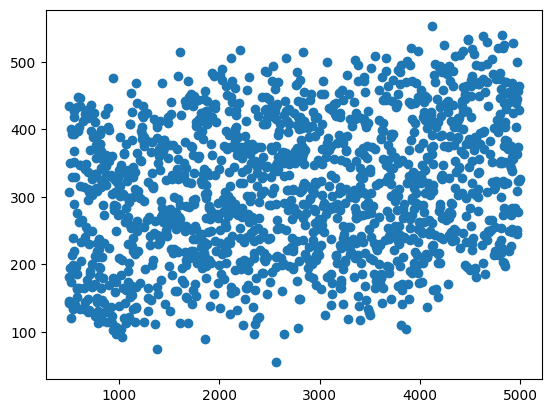

PearsonRResult(statistic=np.float64(0.2370050855081427), pvalue=np.float64(1.3476321928192527e-20))

In [31]:
store_size = df.Store_Size
plt.scatter(store_size, sales)
plt.show()

scipy.stats.pearsonr(sales,store_size)

In [35]:
df.head()

,Sales,Ad_Budget,Store_Size,North,South,West
0,268.093732,44,2836,0,0,0
1,441.660841,96,2656,1,0,0
2,347.500444,76,615,1,0,0
3,297.618111,64,2036,0,0,1
4,203.849511,24,2211,0,0,0


In [39]:
model = ols('Sales~Region',df).fit()
res=sm.stats.anova_lm(model)
print(res)

              df        sum_sq       mean_sq         F    PR(>F)
Region       3.0  8.524669e+04  28415.562482  2.756758  0.041113
Residual  1496.0  1.542017e+07  10307.600751       NaN       NaN


In [40]:
print(pairwise_tukeyhsd(df.Sales, df.Region))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  East  North   1.2061 0.9985 -17.8715 20.2836  False
  East  South   8.8528 0.6263 -10.1059 27.8115  False
  East   West -12.1844 0.3468 -31.0919  6.7232  False
 North  South   7.6467 0.7364 -11.5915 26.8849  False
 North   West -13.3904 0.2762 -32.5782  5.7973  False
 South   West -21.0371 0.0238 -40.1068 -1.9675   True
-----------------------------------------------------


In [41]:
reg_dummy = pd.get_dummies(df.Region,drop_first=True).astype(int)
df = df.drop('Region', axis=1)
df=pd.concat([df,reg_dummy], axis=1)

x_train,x_test,y_train,y_test = train_test_split(df.drop('Sales',axis=1), df.Sales, random_state = 20, test_size=0.1)

x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     2101.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        10:13:36   Log-Likelihood:                -6682.4
No. Observations:                1350   AIC:                         1.338e+04
Df Residuals:                    1344   BIC:                         1.341e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Ad_Budget      3.4885      0.035     98.332      0.0

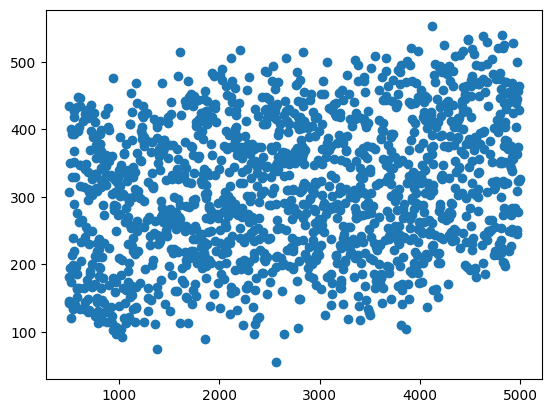

PearsonRResult(statistic=np.float64(0.2370050855081427), pvalue=np.float64(1.3476321928192527e-20))

In [42]:
store_size = df.Store_Size
plt.scatter(store_size, sales)
plt.show()

scipy.stats.pearsonr(sales,store_size)

In [ ]:
y_pred = mod1.predict(x_train)  
residuals = (y_pred-y_train)
np.mean(residuals)


np.float64(-4.69484533554081e-14)

In [46]:
np.median(residuals)


np.float64(-0.977568100656498)

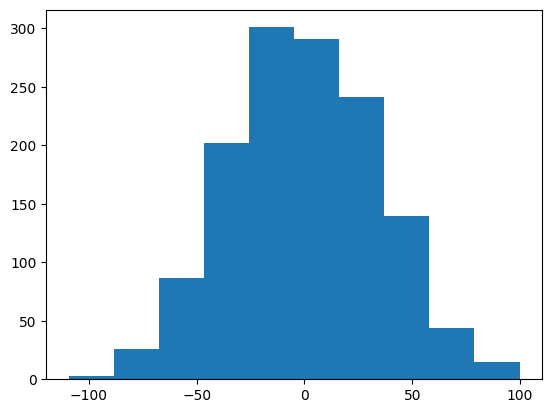

In [44]:
plt.hist(residuals)
plt.show()

In [ ]:
# assumptions for regression - mean of the residuals shoudld be equal to zero
#                            - residuals should follow normal distributions
#                            - residuals and predicted values should not be corelated with each other 

# r-squared -> only for the training set in the OLS result

here we are comparing the scores of pearson and (x_train, y_train regression), they come out to be same

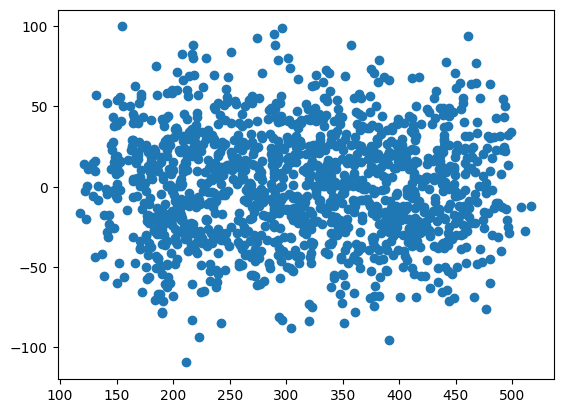

PearsonRResult(statistic=np.float64(-2.2137514755767337e-15), pvalue=np.float64(0.999999999999936))

In [47]:
plt.scatter(y_pred, residuals)
plt.show()
scipy.stats.pearsonr(y_pred, residuals)

In [ ]:
SSE = sum(residuals**2)                    # unexplained variation
SST = sum((y_train-np.mean(y_train))**2)   # total variation
SSR = SST - SSE                            # sum of square due to regression or explained variation

In [ ]:
R2_train = SSR/SST 
R2_train = 1 - SSE/SST

F = (SSR/5)/(SSE/1344)
F                         # compare this in the OLS table

2350.973254142152

In [ ]:
x_test = sm.add_constant(x_test,prepend=False)
y_pred = mod1.predict(x_test)
residuals = (y_pred-y_test) 
SSE = sum(residuals**2)
SST = sum((y_test-np.mean(y_test))**2)
SSR = SST - SSE
R2_test = SSR/SST 
R2_test          # compare this in the ols table we got similar value              

0.8973957003435327

In [62]:
import sklearn
from sklearn.linear_model import LinearRegression

In [69]:
regr1 = LinearRegression()


In [ ]:
regr1.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
regr1.coef_

array([ 3.48853831,  0.01865906, -3.66280797, 11.01888056, -6.00235556,
        0.        ])

In [68]:
regr1.intercept_

np.float64(68.19766387567827)

In [81]:
x1 = np.array([1,2,3,5,3,1,3,5,10])

In [79]:
x1_std = (x1 - np.mean(x1))/np.std(x1)

In [ ]:
x1_std    # dimensionless quantity

array([-1.01600102, -0.63500064, -0.25400025,  0.50800051, -0.25400025,
       -1.01600102, -0.25400025,  0.50800051,  2.41300241])

In [82]:
np.mean(x1_std)

np.float64(9.868649107779169e-17)

In [84]:
np.std(x1_std)

np.float64(0.9999999999999999)

In [112]:
from sklearn.preprocessing import StandardScaler

In [113]:
scl = StandardScaler()

In [ ]:
scld_x1 = scl.fit_transform(x1.reshape(-1,1))     # standardization = mean and std of x1, resulting scld_x1 has mean = 0 and std = 1

In [115]:
scld_x1

array([[-1.01600102],
       [-0.63500064],
       [-0.25400025],
       [ 0.50800051],
       [-0.25400025],
       [-1.01600102],
       [-0.25400025],
       [ 0.50800051],
       [ 2.41300241]])

**Standardization and its results**
- We used scikit-learn's `StandardScaler` to standardize the array `x1`.
- Standardization transforms the data so that it has a mean of 0 and a standard deviation of 1.
- The result, `scld_x1`, is a dimensionless array where each value shows how many standard deviations it is from the mean of the original data.
- This is useful for machine learning algorithms that are sensitive to the scale of input features.

**What we are doing since cell 116:**
1. We created a sample array `x1` and manually standardized it using the formula `(x1 - mean) / std` to understand the process.
2. We verified that the standardized array has mean 0 and standard deviation 1 using `np.mean(x1_std)` and `np.std(x1_std)`.
3. We then used scikit-learn's `StandardScaler` to standardize `x1` in a more automated way, which is the recommended approach for real datasets.
4. The output `scld_x1` confirms that the transformation matches the manual calculation.

**Summary of results:**
- The standardized values (`scld_x1`) are now ready for use in further analysis or modeling.
- Standardization ensures that all features contribute equally to the model and prevents features with larger scales from dominating.
- This step is especially important before applying algorithms like linear regression, logistic regression, or clustering methods.

In [149]:
df = pd.read_excel('data/SalesData1.xlsx')

In [150]:
df.head()

,Sales,Ad_Budget,Store_Size,Region
0,268.093732,44,2836,East
1,441.660841,96,2656,North
2,347.500444,76,615,North
3,297.618111,64,2036,West
4,203.849511,24,2211,East


In [151]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Sales',axis=1), df.Sales, random_state = 20, test_size=0.1)

In [152]:
num_cols = x_train[['Ad_Budget','Store_Size']]
cat_cols = x_train.Region

In [153]:
num_cols = scl.fit_transform(num_cols)

In [154]:
num_cols = pd.DataFrame(num_cols, columns=['Ad_Budget','Store_Size'], index=cat_cols.index)
x_train = pd.concat([num_cols,cat_cols], axis=1)
reg_dummy = pd.get_dummies(x_train.Region,drop_first=True).astype(int)
x_train = x_train.drop('Region', axis=1)
x_train = pd.concat([x_train,reg_dummy], axis=1)

In [155]:
x_train

,Ad_Budget,Store_Size,North,South,West
1392,-1.131234,0.935461,0,0,0
596,0.580580,0.267398,0,1,0
1438,-1.017113,1.560572,1,0,0
415,-0.180226,0.765952,0,1,0
1071,-0.902992,1.401034,0,1,0
...,...,...,...,...,...
924,-0.256307,-0.727410,0,0,1
1247,-1.587718,-1.219061,0,0,1
271,1.075103,0.983782,0,1,0
474,0.086056,-0.695196,0,0,1


In [156]:
mod1.params

Ad_Budget      3.488538
Store_Size     0.018659
North         -3.662808
South         11.018881
West          -6.002356
const         68.197664
dtype: float64

In [163]:
x_test_const = sm.add_constant(x_test, prepend=False)
y_pred1 = mod1.predict(x_test_const)
y_pred2 = mod1.predict(x_test_const)

In [158]:
regr2=LinearRegression()
regr2.fit(x_train,y_train)
print(regr2.intercept_)
print(regr2.coef_)

310.471906136591
[91.70638035 24.32710873 -3.66280797 11.01888056 -6.00235556]


In [159]:
num_cols = x_test[['Ad_Budget','Store_Size']]
cat_cols = x_test.Region
num_cols = scl.transform(num_cols)
num_cols = pd.DataFrame(num_cols, columns=['Ad_Budget','Store_Size'], index=cat_cols.index)
x_test = pd.concat([num_cols,cat_cols], axis=1)
reg_dummy = pd.get_dummies(x_test.Region,drop_first=True).astype(int)
x_test = x_test.drop('Region', axis=1)
x_test = pd.concat([x_test,reg_dummy], axis=1)

In [160]:
y_pred3 = regr2.predict(x_test)

In [161]:
y_pred3[:5]

array([238.86462514, 137.98710356, 369.21924039, 229.79420459,
       438.65570858])

In [162]:
y_pred2[:5]

916     238.864625
312     137.987104
1282    369.219240
1394    229.794205
953     438.655709
dtype: float64

In [164]:
x1

array([ 1,  2,  3,  5,  3,  1,  3,  5, 10])

In [168]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
x1 = x1.reshape(-1,1)
mms.fit_transform(x1)

array([[0.        ],
       [0.11111111],
       [0.22222222],
       [0.44444444],
       [0.22222222],
       [0.        ],
       [0.22222222],
       [0.44444444],
       [1.        ]])

In [170]:
x1_normalized = (x1-min(x1))/(max(x1)-min(x1))              # doing minmaxscaler manually

In [171]:
x1_normalized

array([[0.        ],
       [0.11111111],
       [0.22222222],
       [0.44444444],
       [0.22222222],
       [0.        ],
       [0.22222222],
       [0.44444444],
       [1.        ]])

In [172]:
# robust scaler

In [174]:
x1_robust = x1-np.median(x1)/(np.percentile(x1, 75)-(np.percentile(x1, 25)))

In [175]:
x1_robust

array([[0.],
       [1.],
       [2.],
       [4.],
       [2.],
       [0.],
       [2.],
       [4.],
       [9.]])

In [ ]:
x1_robust = (x1-np.median(x1))/((np.percentile(x1,75))-(np.percentile(x1,25)))

from sklearn.preprocessing import RobustScaler
rs = RobustScaler()
rs.fit_transform(x1.reshape(-1,1))

array([[-0.66666667],
       [-0.33333333],
       [ 0.        ],
       [ 0.66666667],
       [ 0.        ],
       [-0.66666667],
       [ 0.        ],
       [ 0.66666667],
       [ 2.33333333]])

: 

In [1]:
# we can compare the coefficients because they are dimensionless
